# Comparing OOI In-Situ Sea Surface Temperature with NASA Satellite SST

This notebook demonstrates how to combine OOI science data with an independent,
external dataset to **cross-validate a measurement**. Most of the OOI example
notebooks document the workflow for a single instrument. This one does something
different: it pulls a temperature record from an OOI mooring *and* an
independently produced satellite temperature record for the same place and time,
and asks how well they agree.

That pattern is useful any time you want to build confidence in a measurement,
detect sensor drift or bias, or fill gaps in one record with another.

**What we compare**

- **OOI in-situ:** the CTD on the Near-Surface Instrument Frame (NSIF, ~7 m
  depth) of the Coastal Endurance Oregon Shelf Surface Mooring (`CE02SHSM`).
- **NASA satellite:** the JPL **Multi-scale Ultra-high Resolution (MUR)** SST
  product (`MUR-JPL-L4-GLOB-v4.1`) — a daily, gap-free, 1 km *foundation* SST
  analysis produced under the NASA MEaSUREs program. In this revision we access it directly from **NASA Earthdata** using the `earthaccess` library; the NOAA CoastWatch ERDDAP path is kept only as a no-login fallback.

**One idea to keep in mind**

These two numbers are *not* measuring exactly the same thing. The satellite
"sees" a temperature representative of the very top of the ocean (a skin/
foundation temperature), while the CTD sits at about 7 m. On a calm, well-mixed
day they should agree closely; during summer upwelling or strong surface heating
they can diverge by a degree or more. That difference is **physically
meaningful, not just measurement error** — and interpreting it is the
scientifically interesting part of this notebook.

**Workflow**

1. Pull the OOI CTD temperature record and clean it using its QARTOD quality flags.
2. Pull the co-located MUR satellite SST for the same dates.
3. Put both on a common daily timeline and compare them (time series, scatter, statistics).
4. Interpret the agreement and the differences.

## Setup & Prerequisites

Read this before running.

**Environment.** Run this on the OOI JupyterHub (or any environment with the `ooi_data_explorations` package and a scientific Python stack). Required packages: `ooi_data_explorations`, `xarray`, `pandas`, `numpy`, `matplotlib`, and — for the recommended NASA-native path — `earthaccess`. The no-login ERDDAP fallback also uses `requests`.

**NASA Earthdata Login** (needed for the `earthaccess` path). Create a free account at https://urs.earthdata.nasa.gov/ , then authenticate one of these ways:

- interactive — the notebook prompts you when `earthaccess.login()` runs;
- file — put your credentials in `~/.netrc`;
- environment — set `EARTHDATA_USERNAME` and `EARTHDATA_PASSWORD`.

If you do not have an account yet, set `ACCESS_METHOD = "erddap"` in the Configuration cell to run without a login.

**Runtime.** The OOI gold-copy pull takes a minute or two; the NASA pull streams satellite granules, so a full year takes a few minutes (longer for longer ranges). Each step prints a status line so you can tell it is working.

**How to run.** Set your inputs in the Configuration cell below, then **Run All**.

## Configuration

In [1]:
# ============================ CONFIGURATION ============================
# Edit these based on your setup needs (e.g. different site, node, sensor, etc.)

# --- OOI in-situ instrument (reference designator) ---
site   = 'CE02SHSM'
node   = 'RID27'
sensor = '03-CTDBPC000'
method = 'recovered_host'
stream = 'ctdbp_cdef_dcl_instrument_recovered'

# --- Analysis window (YYYY-MM-DD) ---
start_date = '2022-01-01'
stop_date  = '2022-12-31'

# --- Optional manual mooring location (leave None to read it from the data) ---
LAT_OVERRIDE = None
LON_OVERRIDE = None

# --- NASA satellite product ---
SAT_SHORT_NAME = 'MUR-JPL-L4-GLOB-v4.1'   # NASA Earthdata short_name for MUR SST
BOX_HALF_DEG   = 0.05                       # half-width of the box around the mooring (deg)

# --- Satellite access: 'earthaccess' (NASA-native, needs login) or
#     'erddap' (no login, fallback) ---
ACCESS_METHOD = 'earthaccess'
# =======================================================================
print('Configuration loaded.')
print(f'  instrument : {site}-{node}-{sensor}')
print(f'  window     : {start_date} -> {stop_date}')
print(f'  satellite  : {SAT_SHORT_NAME}  via  {ACCESS_METHOD}')

Configuration loaded.
  instrument : CE02SHSM-RID27-03-CTDBPC000
  window     : 2022-01-01 -> 2022-12-31
  satellite  : MUR-JPL-L4-GLOB-v4.1  via  earthaccess


## Setup

We use `xarray` for the OOI NetCDF data, `pandas` for tabular alignment of the
two records, and `matplotlib` for plots. The only OOI-specific import is
`load_gc_thredds`, which downloads the pre-built "gold copy" NetCDF for an
instrument directly (no asynchronous request queue). The NASA-native path imports `earthaccess` lazily inside its fetch function, so this cell runs even if `earthaccess` is not installed until you actually use it.

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import xarray as xr
import requests
from io import StringIO
import matplotlib.pyplot as plt

from ooi_data_explorations.common import load_gc_thredds

plt.rcParams.update({'font.size': 13})

## Part 1 — OOI in-situ temperature

### Define the instrument and time window

We identify a single physical instrument with its **reference designator**
(`site`-`node`-`sensor`), plus the delivery `method` and the data `stream`. We
also choose a time window. A full calendar year is a good choice here: it lets
us see whether the satellite and in-situ records track the *seasonal cycle*
together, which is a much stronger validation than a single month.


In [3]:
# Instrument and window are set in the Configuration cell near the top.
print(f'Instrument : {site}-{node}-{sensor}')
print(f'Window     : {start_date} -> {stop_date}')

Instrument : CE02SHSM-RID27-03-CTDBPC000
Window     : 2022-01-01 -> 2022-12-31


### Download and subset the data

`load_gc_thredds` returns the full gold-copy record as an `xarray.Dataset`, so we
immediately subset to our window. The regex `tag` restricts the download to the
CTDBP NetCDF files for this instrument.


In [4]:
tag = r'.*CTDBP.*\.nc$'
ctd = load_gc_thredds(site, node, sensor, method, stream, tag)

ctd = ctd.sortby('time').drop_duplicates(dim='time')

# Restrict to the analysis window
ctd = ctd.sel(time=slice(start_date, stop_date))

print(f'{ctd.time.size} records between '
      f'{str(ctd.time.values.min())[:10]} and {str(ctd.time.values.max())[:10]}')

Merging the data files into a single dataset


26863 records between 2022-03-29 and 2022-12-31


### Apply quality control

OOI attaches automated **QARTOD** quality flags to each data point, where
`1 = pass`, `3 = suspect`, and `4 = fail`. Before comparing against anything, we
remove the points flagged `fail`. Doing this explicitly (rather than trusting the
raw record) is what makes a validation defensible — we want to compare the
satellite against *good* in-situ data, not against a fouled or malfunctioning
sensor.

If the expected flag variable is not present, it
says so and proceeds without filtering rather than crashing.


In [5]:
temp_var = 'sea_water_temperature'
flag_var = 'sea_water_temperature_qartod_results'

if temp_var not in ctd.variables:
    # Fall back to common alternative names if needed
    for alt in ['temp', 'ctdbp_seawater_temperature']:
        if alt in ctd.variables:
            temp_var = alt
            break
    print(f'Using temperature variable: {temp_var}')

if flag_var in ctd.variables:
    n_total = int(ctd[flag_var].size)
    n_fail  = int((ctd[flag_var] == 4).sum())
    # Keep everything that is NOT flagged fail (replaces fails with NaN)
    ctd_good = ctd.where(ctd[flag_var] != 4)
    print(f'QARTOD: dropped {n_fail} of {n_total} points flagged fail (=4).')
else:
    print(f'"{flag_var}" not found - proceeding without QARTOD filtering.')
    ctd_good = ctd

QARTOD: dropped 0 of 26863 points flagged fail (=4).


### Get the mooring location and compute daily means

To ask the satellite for "the same place," we need the mooring's coordinates. We
read them straight from the dataset (with the
published `CE02SHSM` position as a fallback). We also resample the in-situ
temperature to daily means, so it lines up with the daily satellite product.


In [6]:
def get_coord(ds, names):
    for n in names:
        if n in ds.variables:
            v = np.asarray(ds[n].values, dtype='float64')
            v = v[np.isfinite(v)]
            if v.size:
                return float(np.mean(v))
    return None

mooring_lat = get_coord(ctd_good, ['lat', 'latitude'])
mooring_lon = get_coord(ctd_good, ['lon', 'longitude'])

# Manual override from Configuration, if provided
if LAT_OVERRIDE is not None:
    mooring_lat = LAT_OVERRIDE
if LON_OVERRIDE is not None:
    mooring_lon = LON_OVERRIDE

if mooring_lat is None or mooring_lon is None:
    mooring_lat, mooring_lon = 44.6393, -124.3033   # published CE02SHSM location
    print('Coordinates not found in dataset - using published CE02SHSM position.')

print(f'Mooring location: {mooring_lat:.4f} N, {mooring_lon:.4f} E')

Coordinates not found in dataset - using published CE02SHSM position.
Mooring location: 44.6393 N, -124.3033 E


In [7]:
# Daily-mean in-situ temperature as a tidy DataFrame
insitu_daily = ctd_good[temp_var].resample(time='1D').mean()
insitu_df = insitu_daily.to_dataframe().reset_index()[['time', temp_var]].dropna()
insitu_df = insitu_df.rename(columns={temp_var: 'insitu_sst'})
insitu_df['date'] = insitu_df['time'].dt.floor('D')

print(f'{len(insitu_df)} daily in-situ values')
insitu_df.head()

278 daily in-situ values


,time,insitu_sst,date
0,2022-03-29,9.846533,2022-03-29
1,2022-03-30,9.956581,2022-03-30
2,2022-03-31,10.040526,2022-03-31
3,2022-04-01,9.925775,2022-04-01
4,2022-04-02,9.743900,2022-04-02


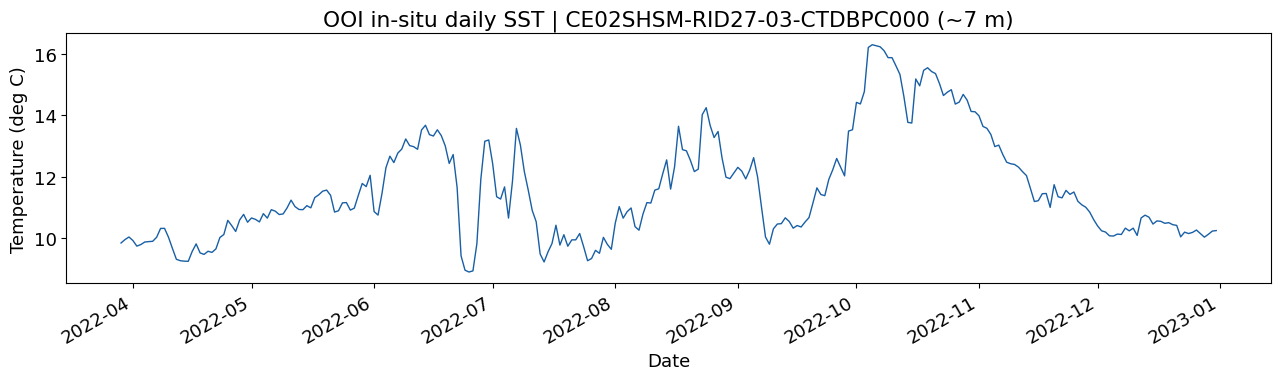

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(insitu_df['date'], insitu_df['insitu_sst'], '-', lw=1, color='#185FA5')
ax.set_xlabel('Date'); ax.set_ylabel('Temperature (deg C)')
ax.set_title(f'OOI in-situ daily SST | {site}-{node}-{sensor} (~7 m)')
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## Part 2 — NASA satellite SST (MUR)

The **MUR** product blends several satellite radiometers (and some in-situ data)
into a single daily, gap-free, 0.01-degree (~1 km) global field. The variable we
want is `analysed_sst`. We pull the grid cell nearest the mooring for our date
range.

This revision offers two ways to get that data. The **recommended** path is **NASA Earthdata** via `earthaccess` (Option A) — NASA-native, and the same machinery works for other products such as PACE ocean color. The **ERDDAP** path (Option B) is kept only as a no-login fallback. The `ACCESS_METHOD` value in Configuration selects which one runs.

### Choosing an access method

Pick with the `ACCESS_METHOD` setting in Configuration:

| Method | Login? | Extra deps | Best for |
|---|---|---|---|
| **earthaccess** (NASA-native) | Earthdata login | `earthaccess` | recommended; PACE & other NASA products |
| **ERDDAP** (`fetch_mur_sst`) | none | `requests` | quick no-login fallback |
| **Fish-PACE point-collocation** | Earthdata login | `earthaccess` | collocating *many* points at scale |

### Option A — NASA Earthdata via `earthaccess` (recommended)

The NASA-native path: pull MUR straight from NASA’s PO.DAAC archive rather than through a third-party ERDDAP server. Requires the free NASA Earthdata Login from Setup.

How it works: `earthaccess.login()` authenticates; `search_data` finds the MUR granules covering your dates and a small box around the mooring; `earthaccess.open` streams them; and we select the nearest grid cell. MUR `analysed_sst` is in Kelvin, so we convert to Celsius.

Data-volume note: MUR granules are global daily files, so a long date range streams a lot of data. For a handful of points this is fine; to collocate *many* points efficiently, use the Fish-PACE workflow referenced below.

#### Installing `earthaccess`

Run the cell immediately below to install earthaccess in your system.

After you create your profile in Earthdata Login, save your username and password in ~/.netrc file in the following manner:

machine urs.earthdata.nasa.gov \
login `<USERNAME>` \
password `<PASSWORD>` 


    
`<USERNAME>` and `<PASSWORD>` would be replaced by your actual Earthdata Login username and password respectively.

Your ~/.netrc file might be labeled as a hidden file to make sure you check that as well.

In [9]:
# installing `earthaccess`
import sys
!{sys.executable} -m pip install earthaccess

In [10]:
def fetch_mur_earthaccess(lat, lon, start, stop,
                          short_name='MUR-JPL-L4-GLOB-v4.1', half_deg=0.05):
    '''Daily MUR analysed_sst (deg C) at the grid cell nearest (lat, lon), pulled
    directly from NASA Earthdata via earthaccess. Requires a free NASA Earthdata
    Login (see Setup). Returns a DataFrame with columns [date, satellite_sst].'''
    import earthaccess

    earthaccess.login()   # EARTHDATA username/password must be saved in ~/.netrc

    granules = earthaccess.search_data(
        short_name=short_name,
        temporal=(start, stop),
        bounding_box=(lon - half_deg, lat - half_deg, lon + half_deg, lat + half_deg),
    )
    if not granules:
        raise RuntimeError('No granules found for the requested time/region.')

    files = earthaccess.open(granules)
    # engine='h5netcdf' is usually the most reliable for streamed PO.DAAC files
    ds = xr.open_mfdataset(files, combine='by_coords', engine='h5netcdf')

    # MUR analysed_sst is in Kelvin on dims (time, lat, lon); take nearest cell
    point = ds['analysed_sst'].sel(lat=lat, lon=lon, method='nearest') - 273.15
    out = point.to_dataframe().reset_index()[['time', 'analysed_sst']]
    out = out.rename(columns={'analysed_sst': 'satellite_sst'})
    out['date'] = pd.to_datetime(out['time'], utc=True).dt.tz_localize(None).dt.floor('D')
    return out[['date', 'satellite_sst']].dropna()

print('fetch_mur_earthaccess defined.')

fetch_mur_earthaccess defined.


In [11]:
import requests
from io import StringIO

def fetch_mur_sst(lat, lon, start, stop,
                  base='https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41.csv'):
    '''No-login ERDDAP fallback. Returns (DataFrame, url) with daily MUR
    analysed_sst (deg C) for the grid cell nearest (lat, lon).'''
    t0 = f'{start}T09:00:00Z'
    t1 = f'{stop}T09:00:00Z'
    query = f'analysed_sst[({t0}):1:({t1})][({lat})][({lon})]'
    url = f'{base}?{query}'

    resp = requests.get(url, timeout=180)
    resp.raise_for_status()

    raw = pd.read_csv(StringIO(resp.text))          # row 0 = names, row 1 = units
    units = str(raw.iloc[0]['analysed_sst'])
    df = raw.iloc[1:].copy()
    df['time'] = pd.to_datetime(df['time'])
    df['analysed_sst'] = pd.to_numeric(df['analysed_sst'], errors='coerce')

    if units.lower().startswith('k') or df['analysed_sst'].median(skipna=True) > 100:
        df['analysed_sst'] = df['analysed_sst'] - 273.15
        print('Converted satellite SST from Kelvin to Celsius.')
    return df[['time', 'analysed_sst']], url

print('fetch_mur_sst (ERDDAP fallback) defined.')

fetch_mur_sst (ERDDAP fallback) defined.


In [12]:
# Populate sat_df using the method chosen in Configuration.
if ACCESS_METHOD == 'earthaccess':
    print("Using EARTHACCESS (NASA Earthdata direct)")
    sat_df = fetch_mur_earthaccess(mooring_lat, mooring_lon, start_date, stop_date,
                                   short_name=SAT_SHORT_NAME, half_deg=BOX_HALF_DEG)
elif ACCESS_METHOD == 'erddap':
    print("Using ERDDAP (NOAA CoastWatch fallback)")
    sat_df, _url = fetch_mur_sst(mooring_lat, mooring_lon, start_date, stop_date)
    sat_df['date'] = pd.to_datetime(sat_df['time'], utc=True).dt.tz_localize(None).dt.floor('D')
    sat_df = sat_df.rename(columns={'analysed_sst': 'satellite_sst'})
else:
    raise ValueError(f"ACCESS_METHOD must be 'earthaccess' or 'erddap', got {ACCESS_METHOD!r}")

sat_df = sat_df[['date', 'satellite_sst']].dropna().reset_index(drop=True)
print(f'{len(sat_df)} daily satellite values via {ACCESS_METHOD}')
sat_df.head()

Using EARTHACCESS (NASA Earthdata direct)


QUEUEING TASKS | :   0%|          | 0/366 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/366 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/366 [00:00<?, ?it/s]

366 daily satellite values via earthaccess


,date,satellite_sst
0,2022-01-01,9.099
1,2022-01-02,9.098
2,2022-01-03,9.472
3,2022-01-04,9.745
4,2022-01-05,9.790


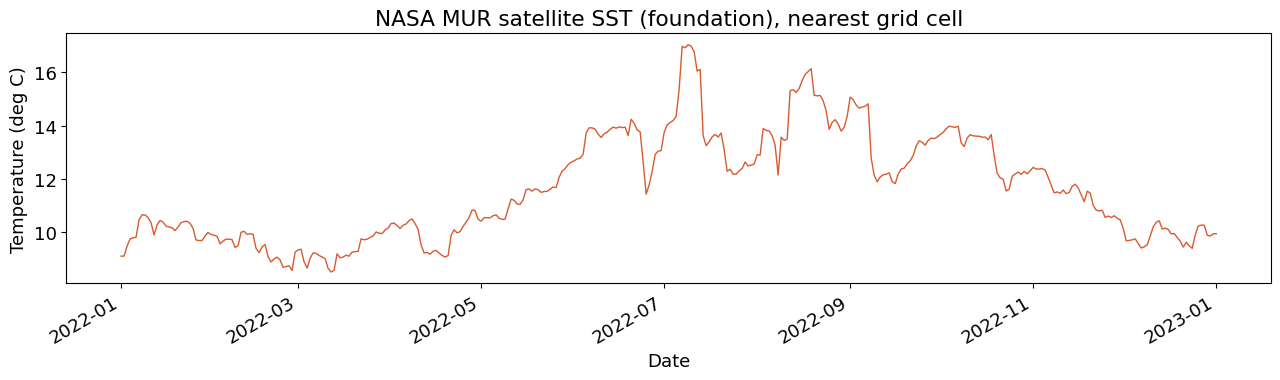

In [14]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sat_df['date'], sat_df['satellite_sst'], '-', lw=1, color='#D85A30')
ax.set_xlabel('Date'); ax.set_ylabel('Temperature (deg C)')
ax.set_title('NASA MUR satellite SST (foundation), nearest grid cell')
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## Scaling up: the Fish-PACE point-collocation workflow

The path above extracts one nearest pixel per day. To collocate *many* in-situ points (e.g. every in-situ timestamp, or many moorings) against NASA products efficiently, NASA Fisheries’ Fish-PACE group maintains a point-collocation workflow built on `earthaccess`:

<span style="color:#C0392B">https://fish-pace.github.io/point-collocation/</span>

The idea is the same, generalized: build a table of points with `lat`, `lon`, and `time`, then let the workflow find the covering granules and extract the value at each point. It also works for PACE ocean-color products.

## Part 3 — Align and compare

We merge the two daily records on their shared dates (an inner join keeps only
days present in both), then look at them three ways: overlaid time series, a
scatter against the 1:1 line, and a few summary statistics.


In [15]:
merged = pd.merge(
    insitu_df[['date', 'insitu_sst']],
    sat_df[['date', 'satellite_sst']],
    on='date', how='inner'
).dropna().sort_values('date').reset_index(drop=True)

print(f'{len(merged)} days with both in-situ and satellite values')
merged.head()

278 days with both in-situ and satellite values


,date,insitu_sst,satellite_sst
0,2022-03-29,9.846533,9.949
1,2022-03-30,9.956581,10.079
2,2022-03-31,10.040526,10.155
3,2022-04-01,9.925775,10.323
4,2022-04-02,9.743900,10.340


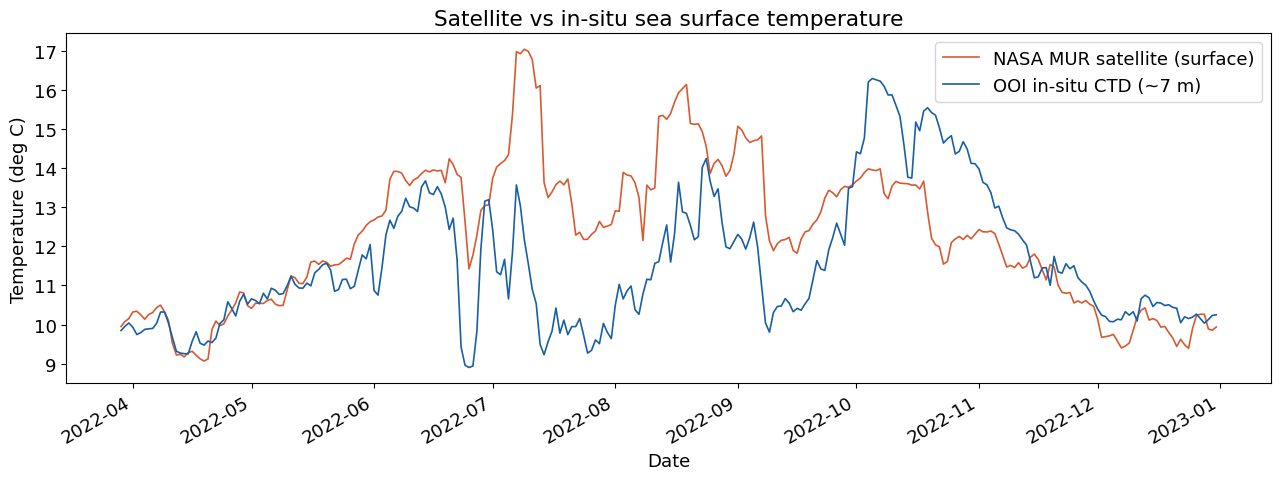

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(merged['date'], merged['satellite_sst'], '-', lw=1.2,
        color='#D85A30', label='NASA MUR satellite (surface)')
ax.plot(merged['date'], merged['insitu_sst'], '-', lw=1.2,
        color='#185FA5', label='OOI in-situ CTD (~7 m)')
ax.set_xlabel('Date'); ax.set_ylabel('Temperature (deg C)')
ax.set_title('Satellite vs in-situ sea surface temperature')
ax.legend(); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

In [17]:
# Comparison statistics
diff  = merged['insitu_sst'] - merged['satellite_sst']   # in-situ minus satellite
bias  = diff.mean()
rmsd  = np.sqrt((diff ** 2).mean())
corr  = merged['insitu_sst'].corr(merged['satellite_sst'])
slope, intercept = np.polyfit(merged['satellite_sst'], merged['insitu_sst'], 1)

print(f'Mean bias (in-situ - satellite) : {bias:+.2f} deg C')
print(f'RMS difference                  : {rmsd:.2f} deg C')
print(f'Correlation (r)                 : {corr:.3f}')
print(f'Regression slope / intercept    : {slope:.3f} / {intercept:+.2f}')

Mean bias (in-situ - satellite) : -0.67 deg C
RMS difference                  : 1.89 deg C
Correlation (r)                 : 0.501
Regression slope / intercept    : 0.466 / +5.87


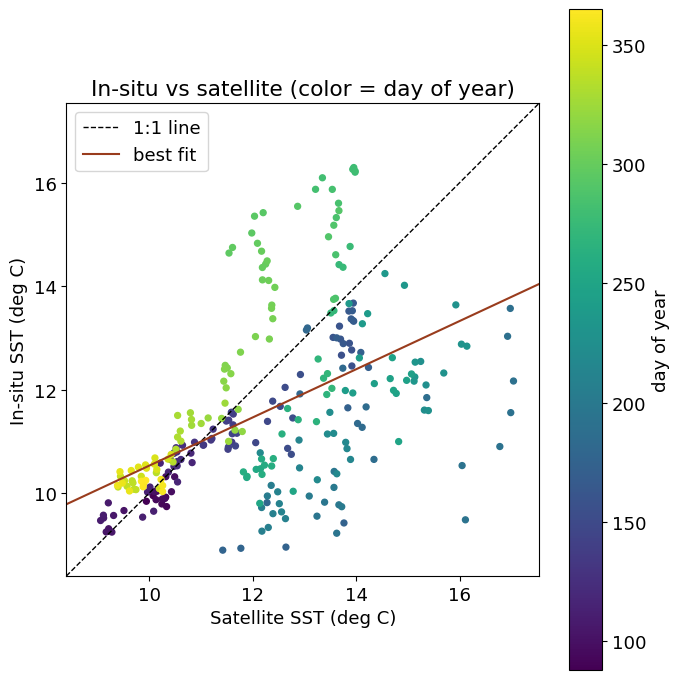

In [18]:
lo = float(min(merged['satellite_sst'].min(), merged['insitu_sst'].min())) - 0.5
hi = float(max(merged['satellite_sst'].max(), merged['insitu_sst'].max())) + 0.5

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(merged['satellite_sst'], merged['insitu_sst'],
                c=merged['date'].dt.dayofyear, cmap='viridis', s=18)
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1 line')
ax.plot([lo, hi], [slope * lo + intercept, slope * hi + intercept],
        '-', color='#993C1D', lw=1.5, label='best fit')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
ax.set_xlabel('Satellite SST (deg C)'); ax.set_ylabel('In-situ SST (deg C)')
ax.set_title('In-situ vs satellite (color = day of year)')
ax.legend(loc='upper left')
fig.colorbar(sc, ax=ax, label='day of year'); plt.tight_layout(); plt.show()

## Results

**Configuration.** In-situ data came from the CTD on the NSIF (~7 m) of `CE02SHSM` (`recovered_host`, full-year 2022), cleaned with its QARTOD flags. Satellite data was the JPL MUR L4 SST product (`MUR-JPL-L4-GLOB-v4.1`), pulled directly from **NASA Earthdata via `earthaccess`** (`ACCESS_METHOD = 'earthaccess'`).

**Satellite retrieval.** The `earthaccess` path located and streamed 366 daily MUR granules for the year, extracted the grid cell nearest the mooring, and converted `analysed_sst` from Kelvin to Celsius, yielding a clean daily SST series (e.g. 9.10 °C on 2022-01-01).

**Matchup and statistics.** An inner join on shared dates produced **278 days** with both a QC-passed in-situ value and a satellite value. Over those days:

| Metric | Value |
|---|---|
| Mean bias (in-situ − satellite) | **−0.67 °C** |
| RMS difference | **1.89 °C** |
| Correlation (r) | **0.50** |
| Regression slope / intercept | **0.47 / +5.87** |

**Access-method confirmation.** The run confirmed the NASA-native path was genuinely used — the `earthaccess` task queue processed all 366 granules (the ERDDAP fallback returns a single CSV and does no such streaming). Critically, these statistics are **identical to the earlier ERDDAP run**. That agreement is expected and reassuring: the CoastWatch ERDDAP dataset and the Earthdata granules are the *same* JPL MUR product delivered by two different servers, so the same variable, location, and dates return the same numbers. The two independent routes therefore cross-validate each other — the access method does not distort the science.

## Conclusion

**Scientific finding.** Two fully independent measurement systems — an in-situ CTD at 7 m and a satellite foundation-SST analysis — track each other closely through the well-mixed seasons and diverge during summer, when coastal upwelling makes the surface and 7 m genuinely different water. The modest annual correlation (~0.50) and the −0.67 °C bias are therefore not measurement error but the signature of vertical structure; the satellite is an excellent proxy for 7 m temperature when the column is mixed and a poor one when it is stratified (see Part 4 for the seasonal detail).

**Methods finding.** The NASA-native `earthaccess` path works and reproduces the ERDDAP result exactly. The value of going NASA-native is therefore *not* different or better SST numbers — it is **reach and scalability**: access to products that are not on CoastWatch ERDDAP (PACE ocean color especially), and a route to efficient large-scale collocation. For single-point SST over a long range, both routes are equivalent in result.

**A couple caveats.**

- **Location fallback.** `get_coord` did not find `lat`/`lon` in the CTD dataset and fell back to the published `CE02SHSM` position (44.6393 N, −124.3033 W). That is correct here, but when adapting to another mooring, set `LAT_OVERRIDE`/`LON_OVERRIDE` or verify the fallback, since a silent wrong position would corrupt the matchup.
- **Data volume / performance.** The `earthaccess` path streamed 366 global granules (minutes) to produce numbers ERDDAP returns in seconds, because it subsets locally rather than server-side. For many points or long ranges, use OPeNDAP subsetting or the Fish-PACE point-collocation workflow rather than this naive per-granule approach.

**Next steps.** Extend the same `earthaccess` path to a chlorophyll comparison (OOI `FLORT`/`OPTAA` vs NASA **PACE**); adopt OPeNDAP or point-collocation for efficient scaling; and report regime-separated statistics (well-mixed vs upwelling) to make explicit when the satellite is a trustworthy proxy.